In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="optuna.distributions")

In [3]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    compare_models_pairwise_r2,
    journal_plot_pack,
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [4]:
BASE_MODEL_DIR = "../resources/models/simulated"
BASE_RESULTS_DIR = "../resources/results/simulated"
FORCE_EXPERIMENTS = (
    True  # set to True to re-run all experiments and overwrite existing results/models
)

filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../resources/data/simulated", filenames)

In [5]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

### Baseline models (GLM and XGBoost)

In [6]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\GLM.pkl


In [7]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM-NoGS",
    fit_poisson_glm,
    {"grid_search": False, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\GLM-NoGS.pkl


In [8]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'tra

In [9]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\XGBoost.pkl


In [10]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost-NoGS",
    fit_poisson_xgboost,
    {"grid_search": False},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\XGBoost-NoGS.pkl


In [11]:
xgboost_results["best_params"]

{0.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estim

### Extractor factory

In [12]:
def make_extractor(extractor_name, n_features, hidden_sizes):
    """
    Factory function for creating feature extractors with a unified interface.

    Parameters
    ----------
    extractor_name : str
        One of {"MLP", "CNN", "RNN"}.
    n_features : int
        Number of input features.
    hidden_sizes : int or sequence of int
        Controls the depth/width of the extractor:
        - CNN: hidden_channels per conv layer
        - RNN: hidden_sizes per GRU layer
        - MLP: ignored (returns None)

    Returns
    -------
    nn.Module or None
        The extractor module, or None for MLP-based shared layers.
    """

    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            hidden_channels=hidden_sizes,
            kernel=3,
            dropout=0.1,
        )

    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_sizes=hidden_sizes,
            dropout=0.1,
        )

    elif extractor_name == "MLP":
        return None

    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS + No-GS)

In [13]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}

nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")

    # For CNN/RNN, we will build extractors inside the grid
    if name == "MLP":
        model_param_grid = nn_model_param_grid_base

    else:
        model_param_grid = {
            "extractor": [
                make_extractor(name, X.shape[0], hs)
                for hs in nn_model_param_grid_base["hidden_sizes"]
            ],
            "hidden_sizes": nn_model_param_grid_base["hidden_sizes"],
        }

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        # force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["GS"] = res


=== Per-Cell NN (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-MLP.pkl

=== Per-Cell NN (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-CNN.pkl

=== Per-Cell NN (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-RNN.pkl


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


In [14]:
# Fixed hidden sizes for No-GS runs
fixed_hidden_sizes = (64, 32)

# No-grid-search versions (fixed extractor)
for name in extractor_names:
    print(f"\n=== Per-Cell NN (No GS) with {name} extractor ===")

    # Build extractor using the new unified interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_hidden_sizes
    )

    if extractor is None:
        # MLP baseline: use hidden_sizes directly in the model
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": fixed_hidden_sizes,
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    else:
        # CNN/RNN: fixed extractor, no grid search
        kwargs = {
            "batch_size": "auto",
            "model_param_grid": {
                "extractor": extractor,
                "hidden_sizes": fixed_hidden_sizes,
            },
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-PerCell-{name}-NoGS",
        fit_poisson_nn,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        # force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    percell_results[name]["NoGS"] = res


=== Per-Cell NN (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-MLP-NoGS.pkl

=== Per-Cell NN (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-CNN-NoGS.pkl

=== Per-Cell NN (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-RNN-NoGS.pkl


In [15]:
tl_results = {
    "deep_shared_shallow_head": {name: {} for name in extractor_names},
    "deep_shared_deep_head": {name: {} for name in extractor_names},
    "shallow_shared_deep_head": {name: {} for name in extractor_names},
}

### Transfer Learning: deep shared hidden and shallow cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [16]:
# Updated hidden-size grid for deep shared extractor
tl_deep_shared_shallow_head_model_param_grid_base = {
    "hidden_sizes": [
        (64,),
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ]
}

tl_deep_shared_shallow_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # For CNN/RNN: hidden_sizes define extractor depth
    # For MLP: extractor = None
    extractor_list = []
    for hs in tl_deep_shared_shallow_head_model_param_grid_base["hidden_sizes"]:
        extractor_list.append(
            make_extractor(extractor_name=name, n_features=X.shape[0], hidden_sizes=hs)
        )

    if name == "MLP":
        # MLP baseline: no extractor, hidden_sizes define shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "hidden_sizes": tl_deep_shared_shallow_head_model_param_grid_base[
                "hidden_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_shallow_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        # force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["GS"] = res


=== TL DeepSharedShallowHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-MLP.pkl

=== TL DeepSharedShallowHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-CNN.pkl

=== TL DeepSharedShallowHead (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-RNN.pkl


In [17]:
# Fixed hidden sizes for No-GS TL run
fixed_hidden_sizes = (256, 128)

# Shared hidden: No-GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedShallowHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_hidden_sizes
    )

    if extractor is None:
        # MLP baseline: shared MLP uses hidden_sizes directly
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": fixed_hidden_sizes,
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    else:
        # CNN/RNN: use extractor as shared feature extractor
        kwargs = {
            "batch_size": "auto",
            "model_params": {
                "shared_extractor": extractor,
                "hidden_sizes": fixed_hidden_sizes,  # shallow head sizes
            },
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-DeepSharedShallowHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        # force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_shallow_head"][name]["NoGS"] = res


=== TL DeepSharedShallowHead (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-MLP-NoGS.pkl

=== TL DeepSharedShallowHead (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-CNN-NoGS.pkl

=== TL DeepSharedShallowHead (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedShallowHead-TL-RNN-NoGS.pkl


### Transfer Learning: deep shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [18]:
tl_deep_shared_deep_head_model_param_grid_base = {
    "shared_sizes": [
        (64,),
        (128,),
        (256,),
        (128, 64),
        (256, 128),
    ],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_deep_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_sizes configuration
    extractor_list = []
    for shared_sizes in tl_deep_shared_deep_head_model_param_grid_base["shared_sizes"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name, n_features=X.shape[0], hidden_sizes=shared_sizes
            )
        )

    if name == "MLP":
        # MLP baseline: shared MLP uses shared_sizes directly
        model_param_grid = {
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        model_param_grid = {
            "shared_extractor": extractor_list,
            "head_sizes": tl_deep_shared_deep_head_model_param_grid_base["head_sizes"],
            "shared_sizes": tl_deep_shared_deep_head_model_param_grid_base[
                "shared_sizes"
            ],
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "deep_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_deep_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        # force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["GS"] = res


=== TL DeepSharedDeepHead (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-MLP.pkl

=== TL DeepSharedDeepHead (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-DeepSharedDeepHead-TL-CNN.pkl

=== TL DeepSharedDeepHead (GS) with RNN extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_extractor': [RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 64, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
), RNNExtractor(
  (rnns): ModuleList(
    (0): GRU(1, 128, batch_first=True, dropout=0.1)
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affin

In [19]:
# Fixed sizes for No-GS TL DeepSharedDeepHead
fixed_shared_sizes = (256, 128)
fixed_head_sizes = (128, 64)

# Nonlinear heads: No-GS
for name in extractor_names:
    print(f"\n=== TL DeepSharedDeepHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=fixed_shared_sizes
    )

    if extractor is None:
        # MLP baseline: shared MLP uses shared_sizes directly
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "deep_shared_deep_head",
            "model_params": {
                "shared_sizes": fixed_shared_sizes,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    else:
        # CNN/RNN: extractor replaces shared MLP
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "deep_shared_deep_head",
            "model_params": {
                "shared_sizes": fixed_shared_sizes,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-DeepSharedDeepHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["deep_shared_deep_head"][name]["NoGS"] = res


=== TL DeepSharedDeepHead (No GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0001
batch_size (default): auto
patience (default): 10
agg_method: median

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]              96
              ReLU-2                   [-1, 16]               0
            Linear-3                   [-1, 32]             544
              ReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 16]             528
              ReLU-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]        

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-DeepSharedDeepHead-TL-RNN-NoGS Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5913
Test log-likelihood:   3528.42
Test deviance:         6.20

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6074
Test log-likelihood:   3388.55
Test deviance:         5.80

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6108
Test log-likelihood:   3132.66
Test deviance:         5.43

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.6025
Test log-likelihood:   3278.14
Test deviance:         5.72

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5768
Test log-likelihood:   3339.13
Test deviance:         6.24

--- Cell 10.0 ---
T

### Transfer Learning: shallow shared hidden and deep cell-specific heads (MLP + CNN + RNN, GS + No-GS)

In [20]:
tl_shallow_shared_deep_head_model_param_grid_base = {
    "shared_dim": [64, 128, 256],
    "head_sizes": [
        (64, 32),
        (128, 64),
        (256, 128),
    ],
}

tl_shallow_shared_deep_head_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (GS) with {name} extractor ===")

    # Build extractors for each shared_dim
    extractor_list = []
    for sd in tl_shallow_shared_deep_head_model_param_grid_base["shared_dim"]:
        extractor_list.append(
            make_extractor(
                extractor_name=name,
                n_features=X.shape[0],
                hidden_sizes=(sd,),  # shallow extractor = 1 layer
            )
        )

    if name == "MLP":
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": [None],
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        model_param_grid = {
            "shared_dim": tl_shallow_shared_deep_head_model_param_grid_base[
                "shared_dim"
            ],
            "head_sizes": tl_shallow_shared_deep_head_model_param_grid_base[
                "head_sizes"
            ],
            "shared_extractor": extractor_list,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shallow_shared_deep_head",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_shallow_shared_deep_head_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["GS"] = res


=== TL ShallowSharedDeepHead (GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0
batch_size (default): auto
patience (default): 10
agg_method: median


=== Starting transfer learning grid search ===
model_param_grid= {'shared_dim': [64, 128, 256], 'head_sizes': [(64, 32), (128, 64), (256, 128)], 'shared_extractor': [None]}
trainer_param_grid= {'l1_lambda': [0.0, 1e-05, 0.0001]}


===== NN-ShallowSharedDeepHead-TL-MLP Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8733
Test log-likelihood:   4490.46
Test deviance:         1.92

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.8605
Test log-likelihood:   4229.91
Test deviance:         2.06

--- Cell 2.0 ---
Train metrics:         (not available)
Val m

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-ShallowSharedDeepHead-TL-RNN Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9226
Test log-likelihood:   4658.73
Test deviance:         1.17

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9212
Test log-likelihood:   4431.62
Test deviance:         1.16

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9171
Test log-likelihood:   4094.72
Test deviance:         1.16

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9289
Test log-likelihood:   4335.72
Test deviance:         1.02

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.9203
Test log-likelihood:   4478.05
Test deviance:         1.18

--- Cell 10.0 ---
Tra

In [21]:
# Fixed sizes for No-GS TL ShallowSharedDeepHead
fixed_shared_dim = 128
fixed_head_sizes = (128, 64)

# First layer: No-GS
for name in extractor_names:
    print(f"\n=== TL ShallowSharedDeepHead (No GS) with {name} extractor ===")

    # Build extractor using unified hidden_sizes interface
    # Shallow extractor = one layer → hidden_sizes = (shared_dim,)
    extractor = make_extractor(
        extractor_name=name, n_features=X.shape[0], hidden_sizes=(fixed_shared_dim,)
    )

    if extractor is None:
        # MLP baseline: shallow shared layer is Linear(n_features → shared_dim)
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shallow_shared_deep_head",
            "model_params": {
                "shared_dim": fixed_shared_dim,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    else:
        # CNN/RNN: extractor replaces shallow Linear layer
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shallow_shared_deep_head",
            "model_params": {
                "shared_dim": fixed_shared_dim,
                "head_sizes": fixed_head_sizes,
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-ShallowSharedDeepHead-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )

    tl_results["shallow_shared_deep_head"][name]["NoGS"] = res


=== TL ShallowSharedDeepHead (No GS) with MLP extractor ===

=== Global training hyperparameters ===
default hidden_sizes: [16]
lr (default): 0.001
epochs (default): 100
weight_decay: 0.0001
l1_lambda (default): 0.0001
batch_size (default): auto
patience (default): 10
agg_method: median

TL fit called with 20 cells, 5 features

=== TL network architecture summary ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]              96
              ReLU-2                   [-1, 16]               0
            Linear-3                   [-1, 32]             544
              ReLU-4                   [-1, 32]               0
            Linear-5                   [-1, 16]             528
              ReLU-6                   [-1, 16]               0
            Linear-7                    [-1, 1]              17
          Softplus-8                    [-1, 1]     

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\torch\nn\modules\rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)



===== NN-ShallowSharedDeepHead-TL-RNN-NoGS Summary =====

--- Cell 0.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5503
Test log-likelihood:   3388.68
Test deviance:         6.82

--- Cell 1.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5533
Test log-likelihood:   3208.85
Test deviance:         6.60

--- Cell 2.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5626
Test log-likelihood:   2981.17
Test deviance:         6.11

--- Cell 3.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5674
Test log-likelihood:   3164.48
Test deviance:         6.23

--- Cell 4.0 ---
Train metrics:         (not available)
Val metrics:           (not available)
Test pseudo-R²:        0.5727
Test log-likelihood:   3325.42
Test deviance:         6.30

--- Cell 10.0 --

### Build comparison lists for GS and No-GS

In [22]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["GS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN",
    ),
]

cells_gs = sorted(glm_results["results"].keys())

In [23]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-RNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-RNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-RNN
0,0.0,0.513104,0.753915,0.833745,0.860948,0.854847,0.516310,0.819881,0.696261,0.903731,0.868643,0.910625,0.873306,0.651857,0.922630
1,1.0,0.507823,0.736288,0.888585,0.878815,0.894901,0.521631,0.827169,0.725605,0.905359,0.875470,0.908501,0.860500,0.657434,0.921183
2,2.0,0.516779,0.752605,0.890952,0.860140,0.887180,0.544892,0.826547,0.730699,0.886631,0.868729,0.906317,0.862571,0.657310,0.917069
3,3.0,0.498979,0.769270,0.882193,0.873491,0.901372,0.527834,0.780498,0.720475,0.910002,0.874480,0.921766,0.884219,0.679755,0.928928
4,4.0,0.503240,0.753150,0.834981,0.883936,0.884837,0.522934,0.824275,0.712795,0.904395,0.866859,0.911555,0.868527,0.669542,0.920254
5,10.0,0.410530,0.677540,0.775343,0.760668,0.751587,0.525965,0.711071,0.696786,0.772178,0.769945,0.762384,0.751342,0.565406,0.776661
6,11.0,0.428363,0.693149,0.778741,0.770456,0.777509,0.511996,0.741512,0.723758,0.769135,0.773549,0.780490,0.757783,0.544028,0.787487
7,12.0,0.468006,0.713012,0.798427,0.767980,0.788730,0.527154,0.699739,0.730397,0.780541,0.774422,0.782546,0.764537,0.498593,0.791620
8,13.0,0.448544,0.703250,0.800820,0.774887,0.787939,0.531667,0.745058,0.707745,0.780437,0.782165,0.786971,0.757942,0.509941,0.794832
9,14.0,0.425316,0.675299,0.754464,0.724692,0.763772,0.536224,0.727089,0.715022,0.749246,0.760670,0.754768,0.735172,0.541101,0.770167


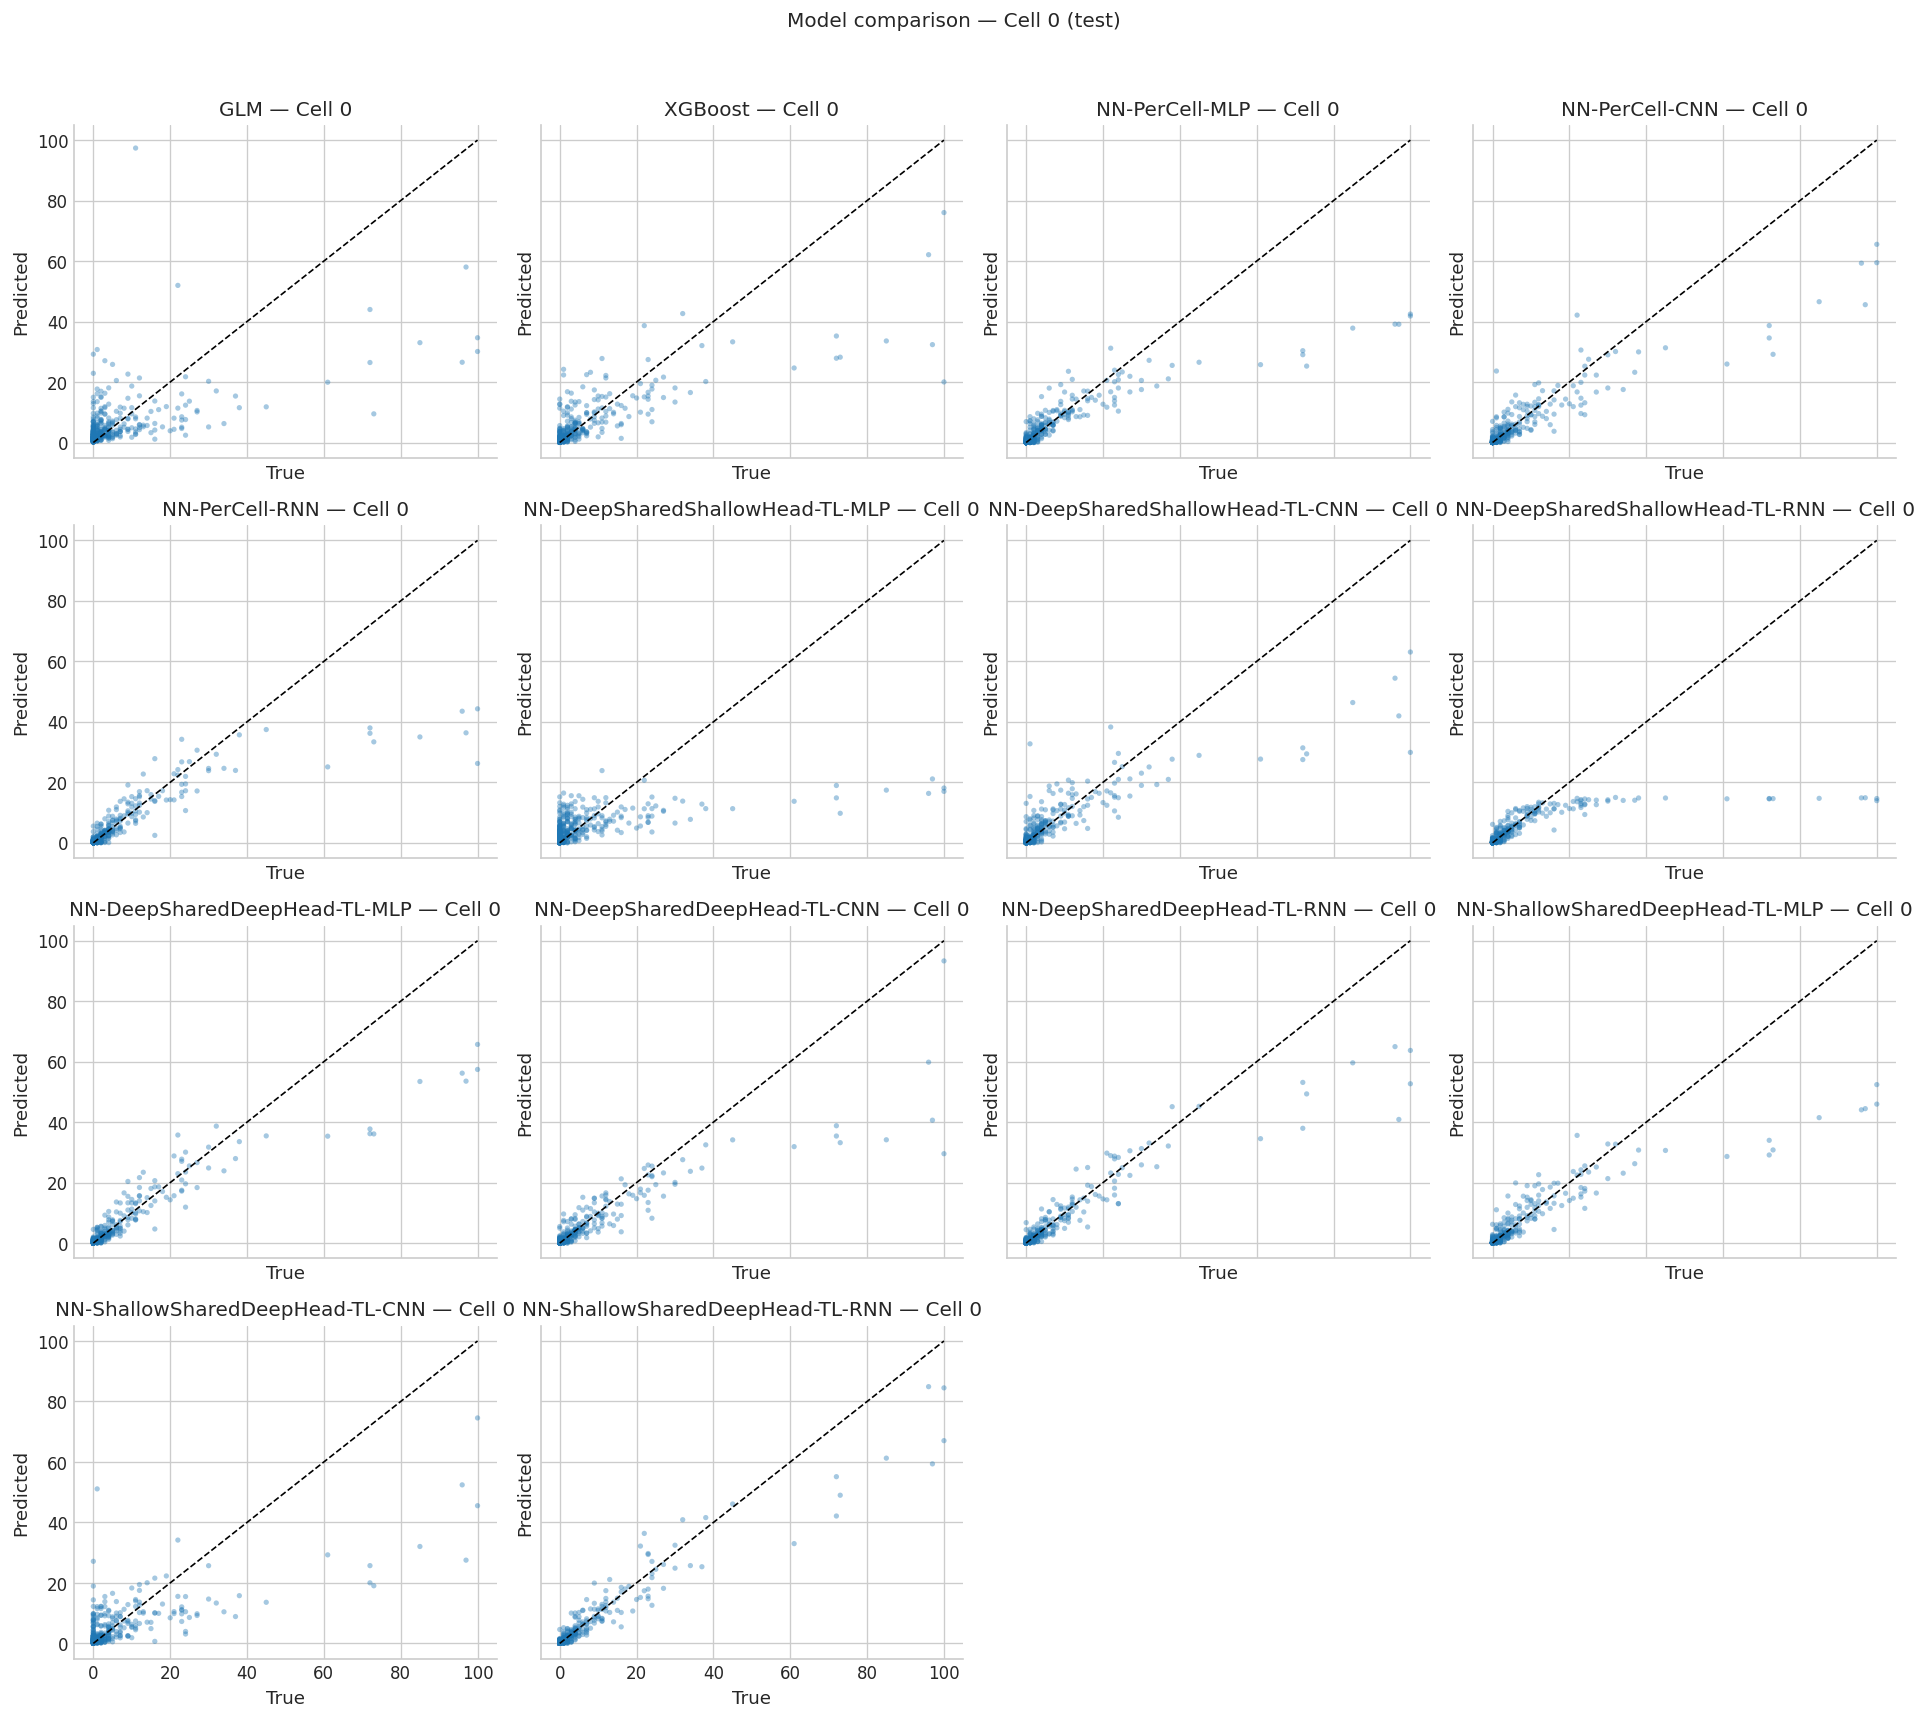

In [24]:
compare_models_for_cell(model_results_gs, cell=0, split="test")

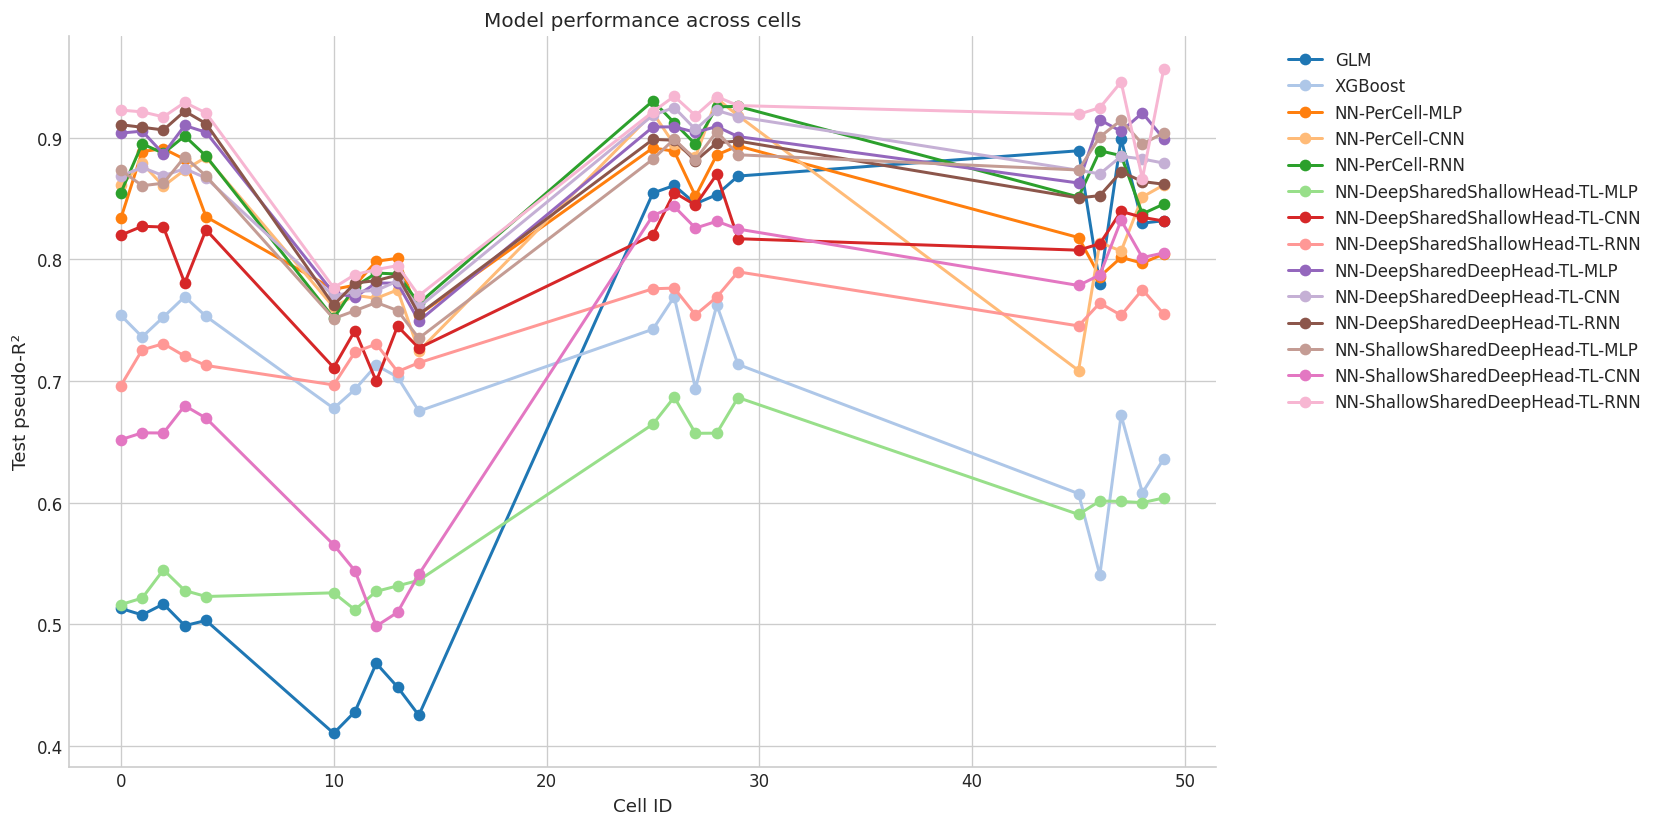

In [25]:
compare_r2_across_cells(model_results_gs, split="test")

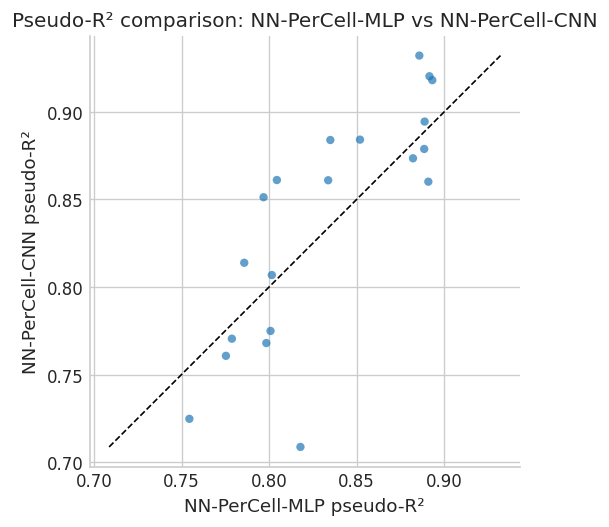

In [26]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [27]:
# No-grid-search results for all models
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (percell_results["MLP"]["NoGS"]["results"], "NN-PerCell-MLP (No GS)"),
    (percell_results["CNN"]["NoGS"]["results"], "NN-PerCell-CNN (No GS)"),
    (percell_results["RNN"]["NoGS"]["results"], "NN-PerCell-RNN (No GS)"),
    (
        tl_results["deep_shared_shallow_head"]["MLP"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-MLP (No GS)",
    ),
    (
        tl_results["deep_shared_shallow_head"]["CNN"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-CNN (No GS)",
    ),
    (
        tl_results["deep_shared_shallow_head"]["RNN"]["NoGS"]["results"],
        "NN-DeepSharedShallowHead-TL-RNN (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["MLP"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-MLP (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["CNN"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-CNN (No GS)",
    ),
    (
        tl_results["deep_shared_deep_head"]["RNN"]["NoGS"]["results"],
        "NN-DeepSharedDeepHead-TL-RNN (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["MLP"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-MLP (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["CNN"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-CNN (No GS)",
    ),
    (
        tl_results["shallow_shared_deep_head"]["RNN"]["NoGS"]["results"],
        "NN-ShallowSharedDeepHead-TL-RNN (No GS)",
    ),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [28]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_nogs = pd.DataFrame(data_rows)
df_test_perf_nogs

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell-MLP (No GS),NN-PerCell-CNN (No GS),NN-PerCell-RNN (No GS),NN-DeepSharedShallowHead-TL-MLP (No GS),NN-DeepSharedShallowHead-TL-CNN (No GS),NN-DeepSharedShallowHead-TL-RNN (No GS),NN-DeepSharedDeepHead-TL-MLP (No GS),NN-DeepSharedDeepHead-TL-CNN (No GS),NN-DeepSharedDeepHead-TL-RNN (No GS),NN-ShallowSharedDeepHead-TL-MLP (No GS),NN-ShallowSharedDeepHead-TL-CNN (No GS),NN-ShallowSharedDeepHead-TL-RNN (No GS)
0,0.0,0.495828,0.787478,0.833522,0.865598,0.875532,0.563226,0.613135,0.314662,0.791403,0.848799,0.591298,0.666612,0.293812,0.550336
1,1.0,0.491330,0.776923,0.890817,0.865830,0.883267,0.583335,0.623666,0.340087,0.784494,0.839167,0.607381,0.673263,0.293453,0.553320
2,2.0,0.487759,0.777255,0.852672,0.859990,0.876238,0.586312,0.625345,0.326476,0.796169,0.838082,0.610786,0.665109,0.286766,0.562561
3,3.0,0.481392,0.781882,0.887725,0.882591,0.887007,0.581796,0.626842,0.339342,0.809638,0.847536,0.602476,0.658224,0.301780,0.567392
4,4.0,0.472272,0.763104,0.870926,0.881749,0.879291,0.571319,0.641288,0.334160,0.791974,0.844679,0.576823,0.642275,0.283334,0.572690
5,10.0,0.413206,0.690789,0.790327,0.734126,0.752967,0.540857,0.398054,0.262243,0.654606,0.682723,0.369367,0.589053,0.252033,0.547024
6,11.0,0.439885,0.710068,0.784709,0.755085,0.777914,0.536467,0.406202,0.302687,0.671359,0.684587,0.400181,0.585871,0.244587,0.540617
7,12.0,0.454806,0.729184,0.803149,0.773857,0.789761,0.560367,0.410673,0.316925,0.682948,0.692878,0.395771,0.599240,0.216481,0.548701
8,13.0,0.438039,0.709677,0.804079,0.763654,0.781478,0.551564,0.417520,0.262708,0.675814,0.688740,0.395727,0.596400,0.221551,0.521880
9,14.0,0.431220,0.694672,0.764535,0.720197,0.751211,0.554201,0.393056,0.321872,0.666605,0.668330,0.372047,0.598369,0.246058,0.541948


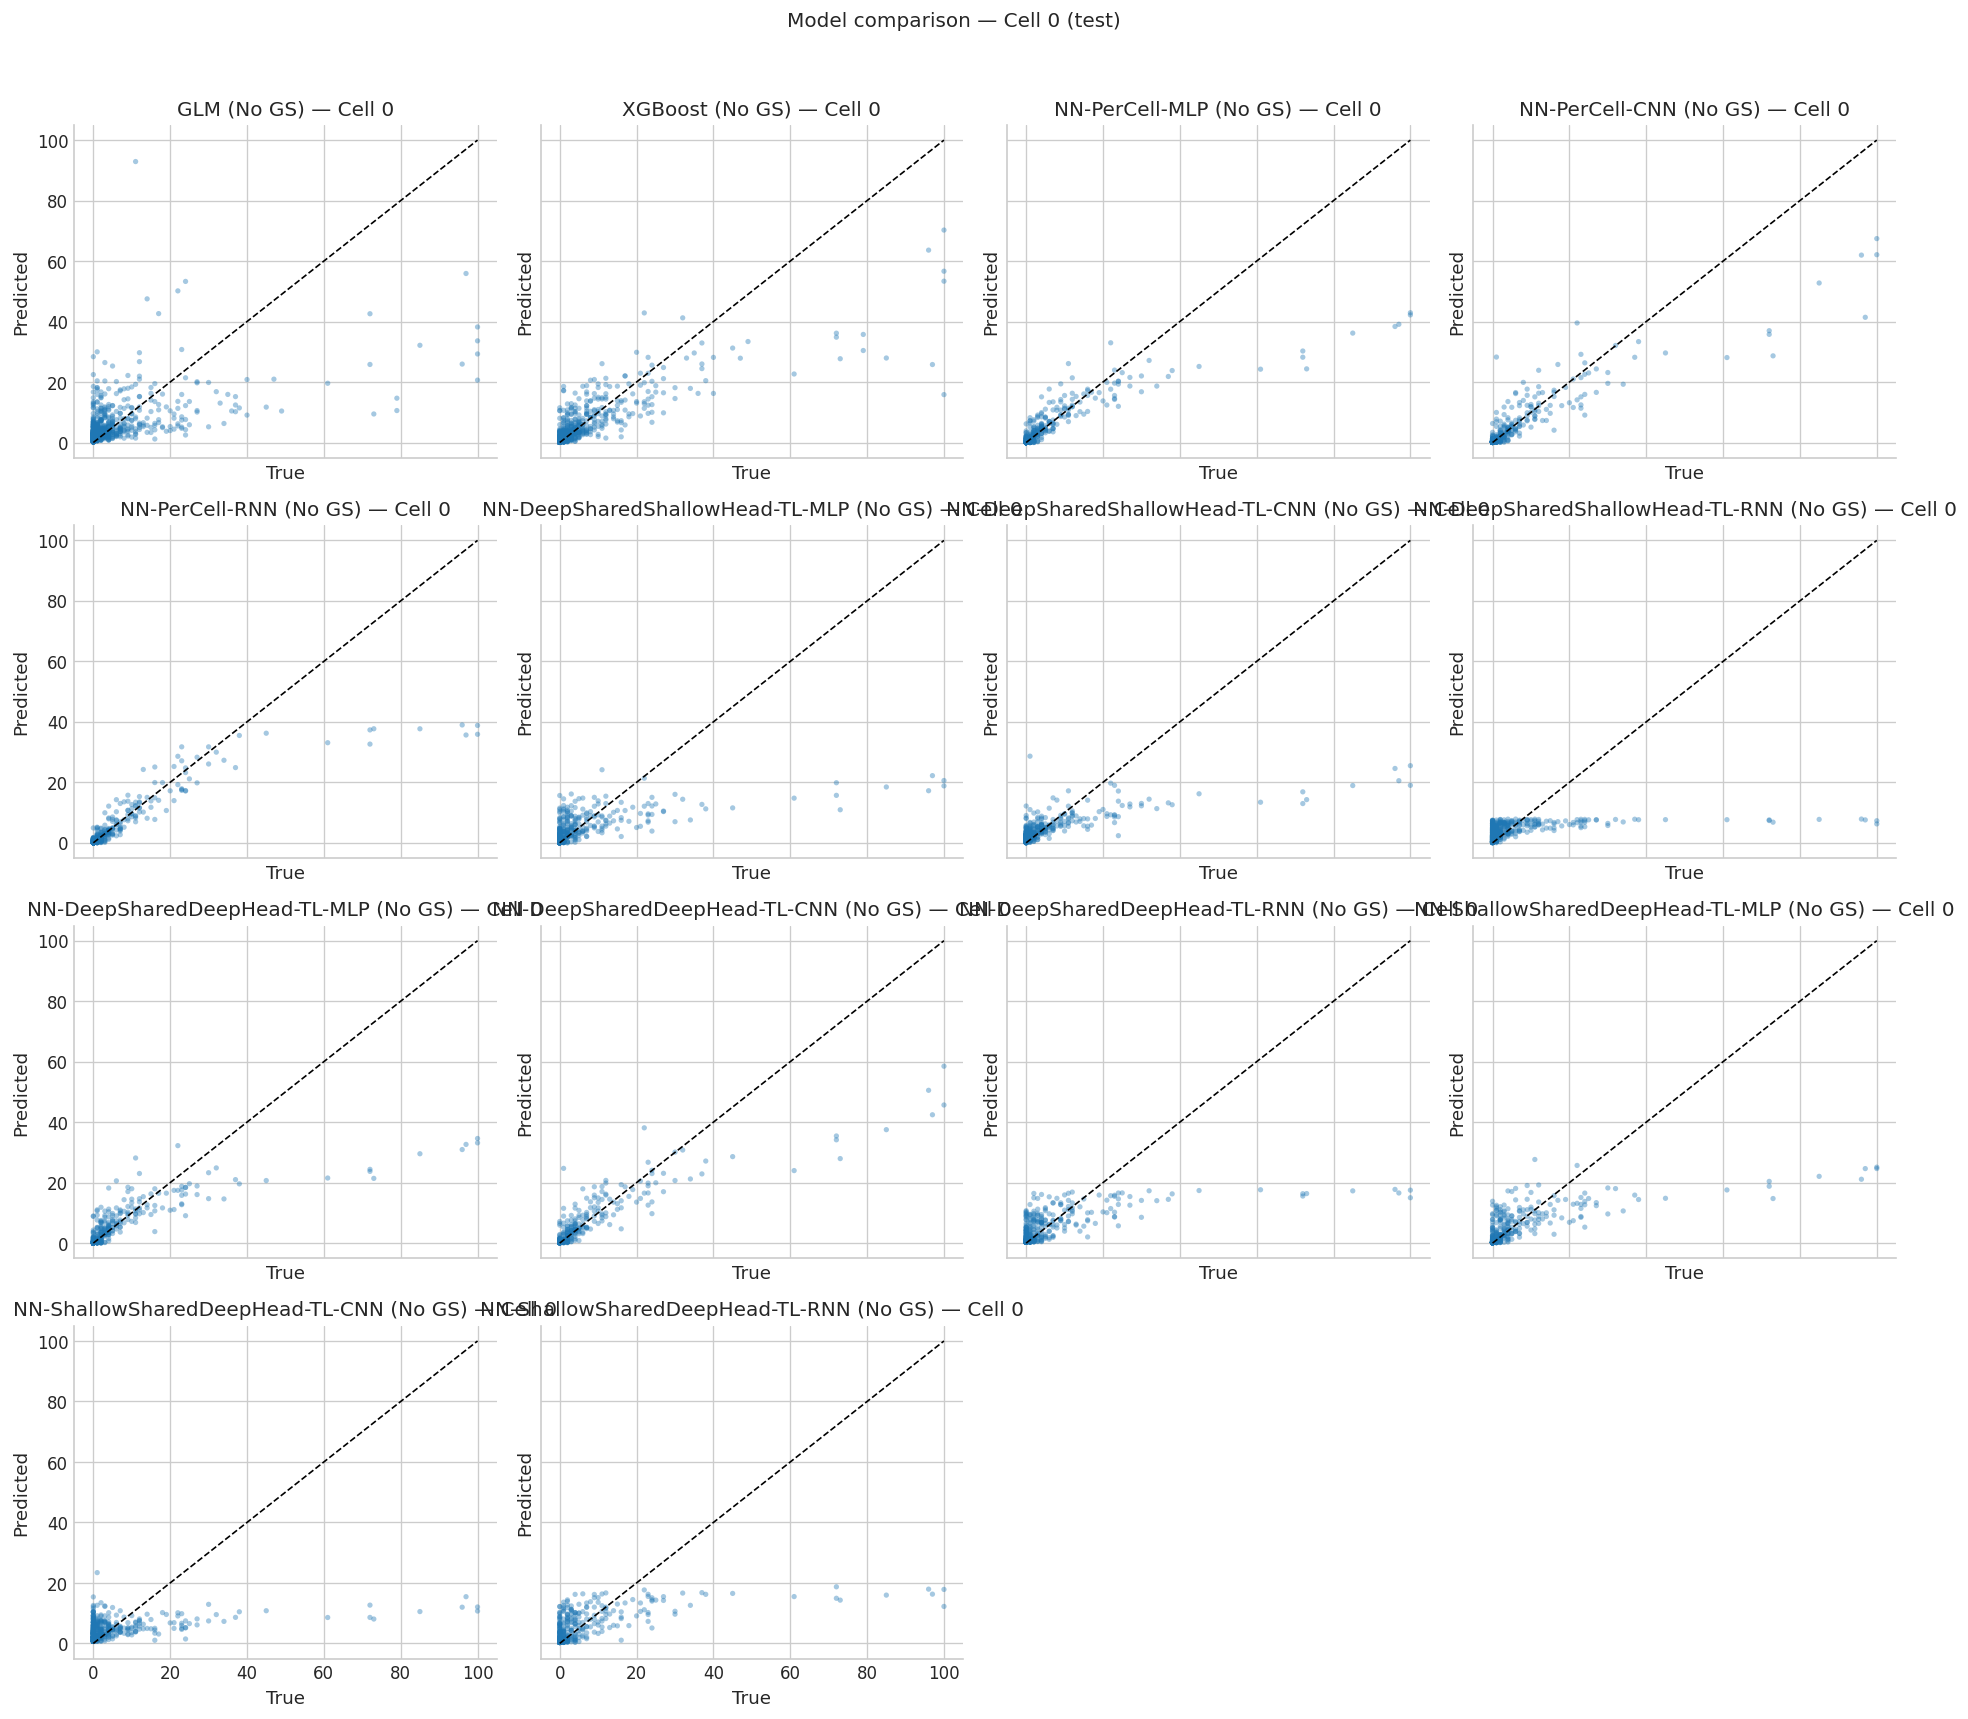

In [29]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

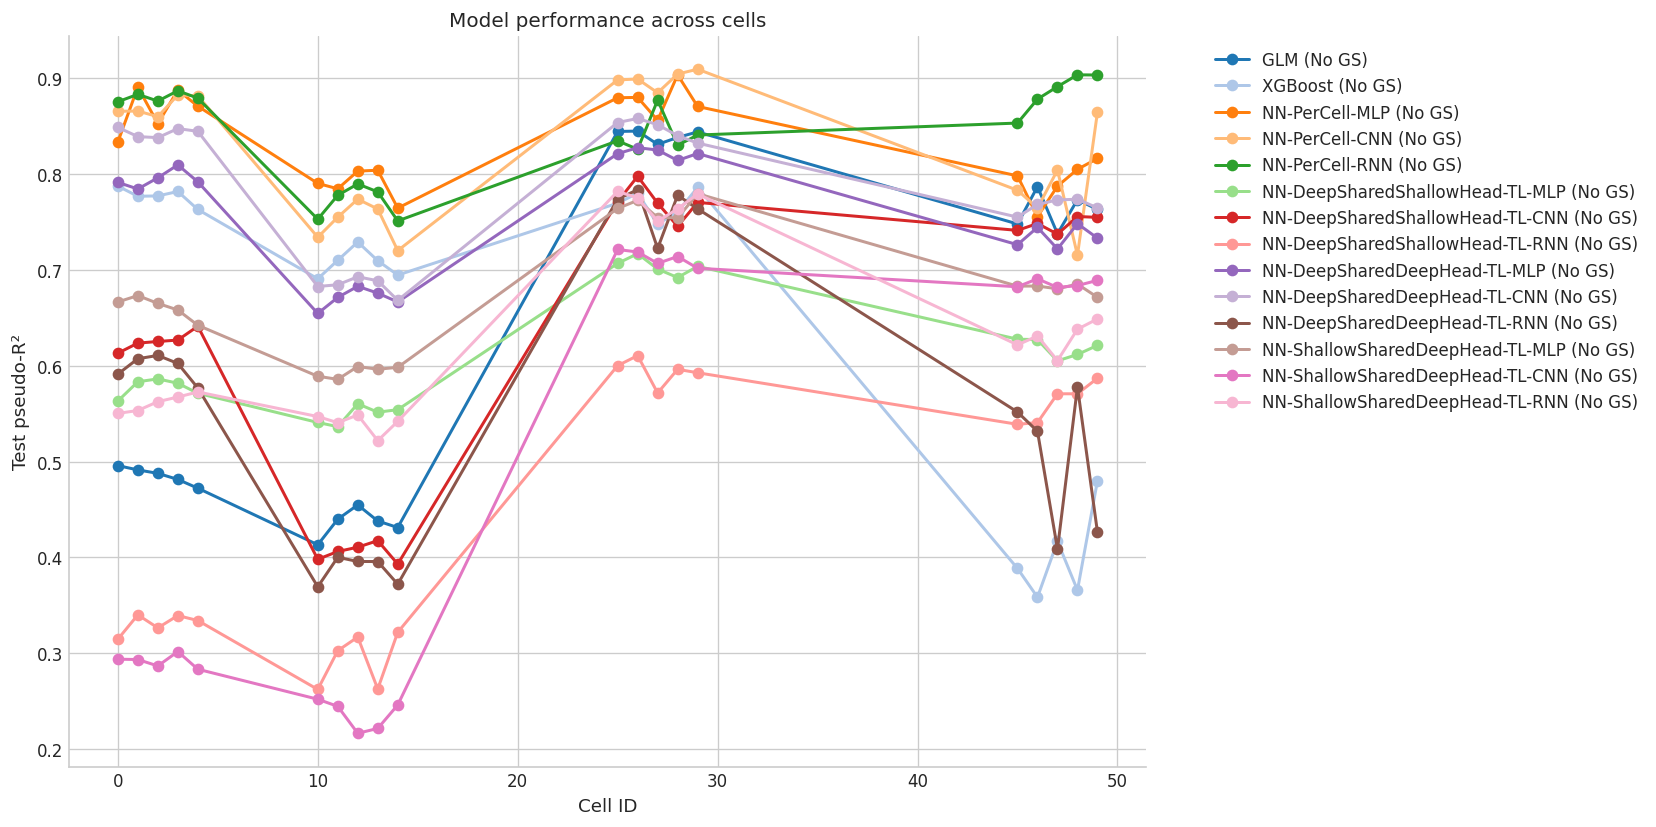

In [30]:
compare_r2_across_cells(model_results_nogs, split="test")

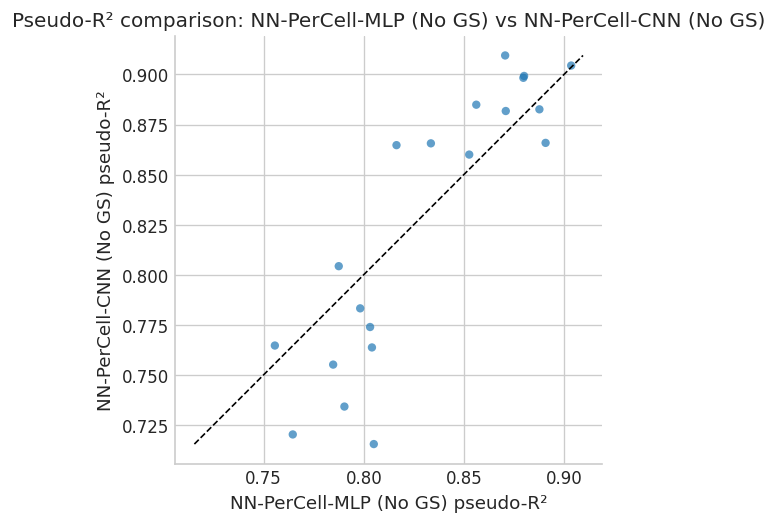

In [31]:
compare_models_pairwise_r2(
    model_results_nogs,
    "NN-PerCell-MLP (No GS)",
    "NN-PerCell-CNN (No GS)",
)

In [32]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 112 plots
  ..\resources\results\simulated\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-DeepSharedDeepHead-TL-RNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-ShallowSharedDeepHead-TL-MLP_vs_NN-ShallowSharedDeepHead-TL-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-ShallowSharedDeepHead-TL-CNN_vs_NN-ShallowSharedDeepHead-TL-RNN.png
